In [1]:
import torch

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1708899/ipykernel_192891/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
import pandas as pd

In [6]:
FOLD = 0

In [7]:
df = pd.read_csv(f"/scratch1/smaruj/genomic_flat_regions/flat_regions_chrom_states_tsv/fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv", sep="\t")

In [8]:
df = df[:10]

In [9]:
boundary_mask_path = "/scratch1/smaruj/generate_genomic_boundary/boundary_indices.pt"

In [10]:
import sys
sys.path.insert(0, "/home1/smaruj/ledidi")
from ledidi import Ledidi

In [11]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
import numpy as np

In [14]:
def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

In [15]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [16]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [17]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [18]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [19]:
from tangermeme.tools import fimo

In [20]:
strength = -0.2

In [21]:
gamma = 300.0

Boundary generation for genome location: chr3:38524928-39835648
Matrix before


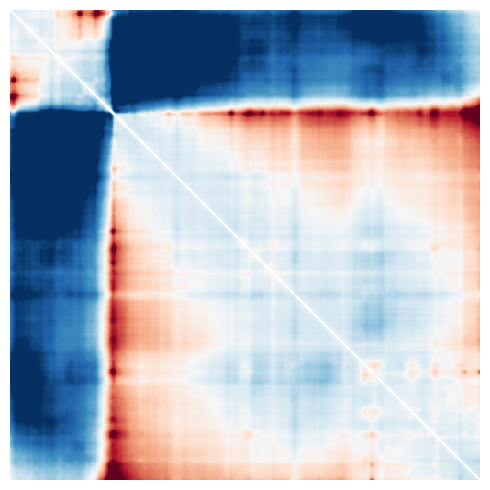

Model in train mode: False
Gradients enabled for weights - slice 0: True
Weights shape - slice 0: torch.Size([1, 4, 2048])
Local loss applied.
iter=I	input_loss=0.0	output_loss=1.309e+04	total_loss=1.309e+04	time=0.0
iter=100	input_loss=367.0	output_loss=6.538e+03	total_loss=6.575e+03	time=8.359
iter=200	input_loss=474.0	output_loss=6.473e+03	total_loss=6.521e+03	time=8.226
iter=300	input_loss=476.0	output_loss=6.491e+03	total_loss=6.538e+03	time=8.225
iter=400	input_loss=478.0	output_loss=6.48e+03	total_loss=6.528e+03	time=8.217
iter=500	input_loss=509.0	output_loss=6.559e+03	total_loss=6.61e+03	time=8.225
iter=600	input_loss=512.0	output_loss=6.601e+03	total_loss=6.652e+03	time=8.232
iter=700	input_loss=517.0	output_loss=6.455e+03	total_loss=6.506e+03	time=8.199
iter=800	input_loss=536.0	output_loss=6.446e+03	total_loss=6.5e+03	time=8.191
iter=900	input_loss=553.0	output_loss=6.471e+03	total_loss=6.526e+03	time=8.592
iter=1000	input_loss=539.0	output_loss=6.516e+03	total_loss=6.57e+0

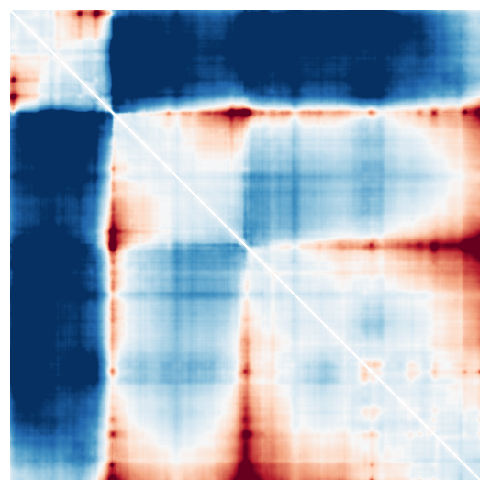

In [22]:
for row in df[2:3].itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    
    print(f"Boundary generation for genome location: {chrom}:{pred_start}-{pred_end}")
    
    X = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt", weights_only=True, map_location=device)
    target = torch.load(f"/scratch1/smaruj/generate_genomic_boundary/targets/target_{strength}/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt", weights_only=True, map_location=device)
    tower_output_path = f"/scratch1/smaruj/generate_genomic_boundary/tower_outputs/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_tower_out.pt"
    
    model.eval()
    with torch.no_grad():
        pred_before = model(X)
    
    matrix_to_plot_before = from_upper_triu(pred_before[0, 0, :], matrix_len=512, num_diags=2)
    
    print("Matrix before")
    plot_map(matrix_to_plot_before)
    
    wrapper = Ledidi(model, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),
                 batch_size=1,
                 l=0.1,
                 max_iter=2000,
                 early_stopping_iter=2000,
                 return_history=False,
                 verbose=True,
                 bin_size=2048,
                 input_mask_slices_0=[256], # mid-bin
                 cropping_applied=64,
                 output_mask_path=boundary_mask_path,
                 use_semifreddo=True,
                 semifreddo_temp_output_path=tower_output_path,
                 g=gamma,
                 punish_ctcf=False,
                 ctcf_meme_path=CTCF_PWM,
                 ).cuda()
    
    slice_0_torch = X[:, :, slice_0_start:slice_0_end]
    
    x_bar_slice_0, last_update, _, _, _ = wrapper.fit_transform(X=slice_0_torch, y_bar=target)
    
    torch.save(x_bar_slice_0[:,:,padding:-padding], f"/scratch1/smaruj/CTCF_elimination/gamma_{gamma}/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_slice.pt")
    
    X_new = X.clone()
    X_new[:,:,slice_0_start:slice_0_end] = x_bar_slice_0

    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=x_bar_slice_0[:, :, 4096:-4096],
        threshold=1e-4,
        reverse_complement=True
    )[0]
    
    print(hits)
    
    model.eval()
    with torch.no_grad():
        pred_after = model(X_new)
    
    matrix_to_plot_after = from_upper_triu(pred_after[0, 0, :], matrix_len=512, num_diags=2)
    
    print("Matrix after")
    plot_map(matrix_to_plot_after)
    

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_before.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_before.svg", format='svg')
plt.show()

<Figure size 800x800 with 0 Axes>

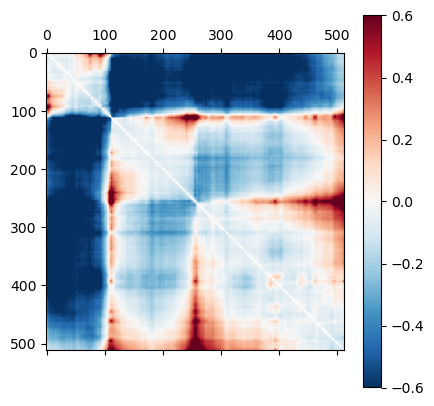

In [23]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_after.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.savefig("map_3ctcfs.svg", format='svg')
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_after-matrix_to_plot_before.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_difference.svg", format='svg')
plt.show()